# Palindrome LSTM Accuracy Study

This notebook addresses Part I Task 2: train the LSTM from Task 1 across different palindrome lengths and compare with Vanilla RNN results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from argparse import Namespace
import importlib

from dataset import PalindromeDataset
from lstm import LSTM
import train as train_module
importlib.reload(train_module)
from train import train, evaluate, main
from utils import AverageMeter, accuracy

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
import sys
import io

def train_lstm_model(
    seq_length,
    num_epochs=50,
    batch_size=128,
    hidden_dim=128,
    learning_rate=1e-3,
    data_size=10000,
    max_norm=10.0,
    verbose=True
):
    """
    Train LSTM model for a given sequence length.
    Reuses main() function from train.py.
    """
    input_length = seq_length - 1
    
    # Build config namespace to match train.py interface
    config = Namespace(
        input_length=input_length,
        input_dim=1,
        num_classes=10,
        num_hidden=hidden_dim,
        batch_size=batch_size,
        learning_rate=learning_rate,
        max_norm=max_norm,
        max_epoch=num_epochs,
        data_size=data_size,
        portion_train=0.8,
    )
    
    if not verbose:
        old_stdout = sys.stdout
        sys.stdout = io.StringIO()
    
    model, train_acc, val_acc = main(config)
    
    if not verbose:
        sys.stdout = old_stdout
    
    return model, train_acc, val_acc

In [4]:
def train_lstm_model_with_history(
    seq_length,
    num_epochs=50,
    batch_size=128,
    hidden_dim=128,
    learning_rate=1e-3,
    data_size=10000,
    max_norm=10.0,
    verbose=True,
    log_every=1,
):
    """Train LSTM and return per-epoch history for plotting."""
    input_length = seq_length - 1
    config = Namespace(
        input_length=input_length,
        input_dim=1,
        num_classes=10,
        num_hidden=hidden_dim,
        batch_size=batch_size,
        learning_rate=learning_rate,
        max_norm=max_norm,
        max_epoch=num_epochs,
        data_size=data_size,
        portion_train=0.8,
    )

    model = LSTM(
        seq_length=config.input_length,
        input_dim=config.input_dim,
        hidden_dim=config.num_hidden,
        output_dim=config.num_classes,
    ).to(device)

    dataset = PalindromeDataset(
        input_length=config.input_length,
        total_len=config.data_size,
    )
    train_size = int(config.portion_train * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.RMSprop(model.parameters(), lr=config.learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(num_epochs):
        if verbose:
            print(f"\nEpoch {epoch + 1}/{num_epochs}")
        train_loss, train_acc = train_module.train(
            model, train_loader, optimizer, criterion, device, config
        )
        val_loss, val_acc = train_module.evaluate(
            model, val_loader, criterion, device, config
        )
        scheduler.step()

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose and ((epoch + 1) % log_every == 0):
            print(
                f"Epoch {epoch + 1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
                f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}"
            )

    return model, history

## Task 2: Test with T=5

First, verify that LSTM can achieve close to perfect accuracy with T=5.

### Loss and Accuracy Curves for T=5

To visualize how the LSTM converges when \(T=5\), we retrain the model while keeping a compact per-epoch history (logging every few epochs to avoid overly dense plots).

In [5]:
print("Training LSTM with T=5 and collecting history")
model_t5_hist, history_t5 = train_lstm_model_with_history(
    seq_length=5,
    num_epochs=50,
    verbose=True,
    log_every=5,
)
print(
    f"\nHistory collected for {len(history_t5['epoch'])} epochs. "
    f"Final Train Acc={history_t5['train_acc'][-1]:.4f}, Val Acc={history_t5['val_acc'][-1]:.4f}"
)

Training LSTM with T=5 and collecting history
Setting total_len to the maximum possible length. 

Epoch 1/50
[0/7] Loss: 2.324240 (2.324240) Accuracy: 0.070312 (0.070312)
[0/2] Loss: 2.306476 (2.306476) Accuracy: 0.132812 (0.132812)

Epoch 2/50
[0/7] Loss: 2.295195 (2.295195) Accuracy: 0.132812 (0.132812)
[0/2] Loss: 2.220862 (2.220862) Accuracy: 0.187500 (0.187500)

Epoch 3/50
[0/7] Loss: 2.230183 (2.230183) Accuracy: 0.179688 (0.179688)
[0/2] Loss: 2.029711 (2.029711) Accuracy: 0.148438 (0.148438)

Epoch 4/50
[0/7] Loss: 2.003294 (2.003294) Accuracy: 0.218750 (0.218750)
[0/2] Loss: 1.826780 (1.826780) Accuracy: 0.187500 (0.187500)

Epoch 5/50
[0/7] Loss: 1.719390 (1.719390) Accuracy: 0.265625 (0.265625)
[0/2] Loss: 1.550138 (1.550138) Accuracy: 0.437500 (0.437500)
Epoch 5: Train Loss=1.6608, Train Acc=0.3475, Val Loss=1.5480, Val Acc=0.4400

Epoch 6/50
[0/7] Loss: 1.543568 (1.543568) Accuracy: 0.453125 (0.453125)
[0/2] Loss: 1.506379 (1.506379) Accuracy: 0.226562 (0.226562)

Epoch 7/

The history dictionary stores per-epoch train/validation metrics. To keep the plot legible, we down-sample the points (every two epochs) before plotting.

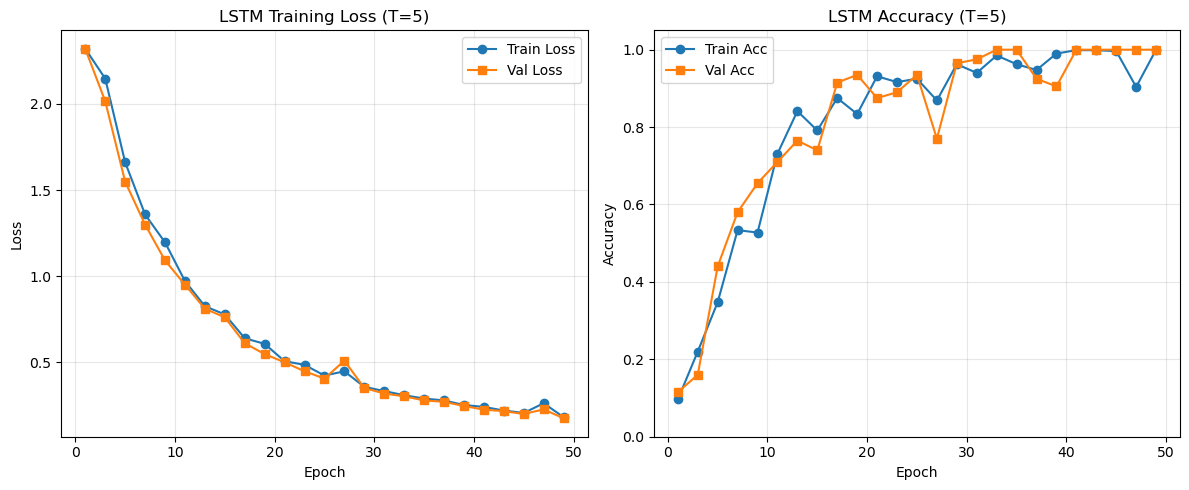

Saved plot to t5_training_curves.png


In [6]:
downsample_step = 2  # keep every other epoch to avoid clutter

epochs = np.array(history_t5["epoch"])[::downsample_step]
train_loss = np.array(history_t5["train_loss"])[::downsample_step]
val_loss = np.array(history_t5["val_loss"])[::downsample_step]
train_acc = np.array(history_t5["train_acc"])[::downsample_step]
val_acc = np.array(history_t5["val_acc"])[::downsample_step]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label="Train Loss", marker='o')
plt.plot(epochs, val_loss, label="Val Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training Loss (T=5)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label="Train Acc", marker='o')
plt.plot(epochs, val_acc, label="Val Acc", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Accuracy (T=5)")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('t5_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot to t5_training_curves.png")

In [4]:
print("Training LSTM with T=5 (input_length=4)")
model_t5, train_acc_t5, val_acc_t5 = train_lstm_model(
    seq_length=5,
    num_epochs=50,
    verbose=True
)
print(f"\nFinal Results for T=5: Train Acc={train_acc_t5:.4f}, Val Acc={val_acc_t5:.4f}")

Training LSTM with T=5 (input_length=4)
Using device: cpu
Setting total_len to the maximum possible length. 

Epoch 1/50
[0/7] Loss: 2.319052 (2.319052) Accuracy: 0.078125 (0.078125)
[0/2] Loss: 2.286985 (2.286985) Accuracy: 0.109375 (0.109375)
Epoch 1: Train Loss=2.3185, Train Acc=0.0762, Val Loss=2.2916, Val Acc=0.1000

Epoch 2/50
[0/7] Loss: 2.248287 (2.248287) Accuracy: 0.117188 (0.117188)
[0/2] Loss: 2.157007 (2.157007) Accuracy: 0.156250 (0.156250)
Epoch 2: Train Loss=2.2197, Train Acc=0.1675, Val Loss=2.1644, Val Acc=0.1700

Epoch 3/50
[0/7] Loss: 2.134508 (2.134508) Accuracy: 0.234375 (0.234375)
[0/2] Loss: 1.876212 (1.876212) Accuracy: 0.320312 (0.320312)
Epoch 3: Train Loss=2.0193, Train Acc=0.2412, Val Loss=1.8929, Val Acc=0.2900

Epoch 4/50
[0/7] Loss: 1.823636 (1.823636) Accuracy: 0.335938 (0.335938)
[0/2] Loss: 1.744556 (1.744556) Accuracy: 0.296875 (0.296875)
Epoch 4: Train Loss=1.8139, Train Acc=0.2838, Val Loss=1.7583, Val Acc=0.3000

Epoch 5/50
[0/7] Loss: 1.694771 (1

## Accuracy Sweep Over Palindrome Length

Train LSTM for each palindrome length and record validation accuracy.

In [5]:
lengths = [5, 10, 15, 20, 25, 30]
# for longer sequences (e.g., length 35+), the half_length becomes large (17+), 
# making max_num = 10^17 exceed numpy's maximum integer limit for random sampling.
# Therefore, we only choose lengths less than 35 to train.

num_epochs = 50

lstm_results = []
for seq_len in lengths:
    print(f"\n=== Training LSTM with sequence length {seq_len} ===")
    model, train_acc, val_acc = train_lstm_model(
        seq_length=seq_len,
        num_epochs=num_epochs,
        verbose=False
    )
    lstm_results.append({
        "length": seq_len,
        "train_acc": train_acc,
        "eval_acc": val_acc,
    })
    print(f"Length {seq_len}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

lstm_results


=== Training LSTM with sequence length 5 ===
Length 5: Train Acc=1.0000, Val Acc=1.0000

=== Training LSTM with sequence length 10 ===
Length 10: Train Acc=1.0000, Val Acc=1.0000

=== Training LSTM with sequence length 15 ===
Length 15: Train Acc=1.0000, Val Acc=1.0000

=== Training LSTM with sequence length 20 ===
Length 20: Train Acc=1.0000, Val Acc=1.0000

=== Training LSTM with sequence length 25 ===
Length 25: Train Acc=1.0000, Val Acc=1.0000

=== Training LSTM with sequence length 30 ===
Length 30: Train Acc=1.0000, Val Acc=1.0000


[{'length': 5, 'train_acc': 1.0, 'eval_acc': 1.0},
 {'length': 10, 'train_acc': 1.0, 'eval_acc': 1.0},
 {'length': 15, 'train_acc': 1.0, 'eval_acc': 1.0},
 {'length': 20, 'train_acc': 1.0, 'eval_acc': 1.0},
 {'length': 25, 'train_acc': 1.0, 'eval_acc': 1.0},
 {'length': 30, 'train_acc': 1.0, 'eval_acc': 1.0}]

## RNN Results from Assignment 2

Results from Vanilla RNN implementation for comparison.

In [6]:
# RNN results from Assignment 2
rnn_results = [
    {'length': 5, 'train_acc': 0.9140625, 'eval_acc': 0.9944087009803921},
    {'length': 10, 'train_acc': 0.8984375, 'eval_acc': 0.8720128676470589},
    {'length': 15, 'train_acc': 0.8671875, 'eval_acc': 0.8671109068627451},
    {'length': 20, 'train_acc': 0.3046875, 'eval_acc': 0.4739583333333333},
    {'length': 25, 'train_acc': 0.0625, 'eval_acc': 0.0978860294117647},
    {'length': 30, 'train_acc': 0.078125, 'eval_acc': 0.09719669117647059},
    {'length': 35, 'train_acc': 0.0859375, 'eval_acc': 0.10033700980392157},
    {'length': 40, 'train_acc': 0.078125, 'eval_acc': 0.09934129901960784},
    {'length': 45, 'train_acc': 0.0546875, 'eval_acc': 0.10340073529411764},
    {'length': 50, 'train_acc': 0.109375, 'eval_acc': 0.10294117647058823}
]

print("RNN Results from Assignment 2:")
for r in rnn_results:
    print(f"Length {r['length']}: Eval Acc={r['eval_acc']:.4f}")

RNN Results from Assignment 2:
Length 5: Eval Acc=0.9944
Length 10: Eval Acc=0.8720
Length 15: Eval Acc=0.8671
Length 20: Eval Acc=0.4740
Length 25: Eval Acc=0.0979
Length 30: Eval Acc=0.0972
Length 35: Eval Acc=0.1003
Length 40: Eval Acc=0.0993
Length 45: Eval Acc=0.1034
Length 50: Eval Acc=0.1029


## Comparison Plot: LSTM vs RNN

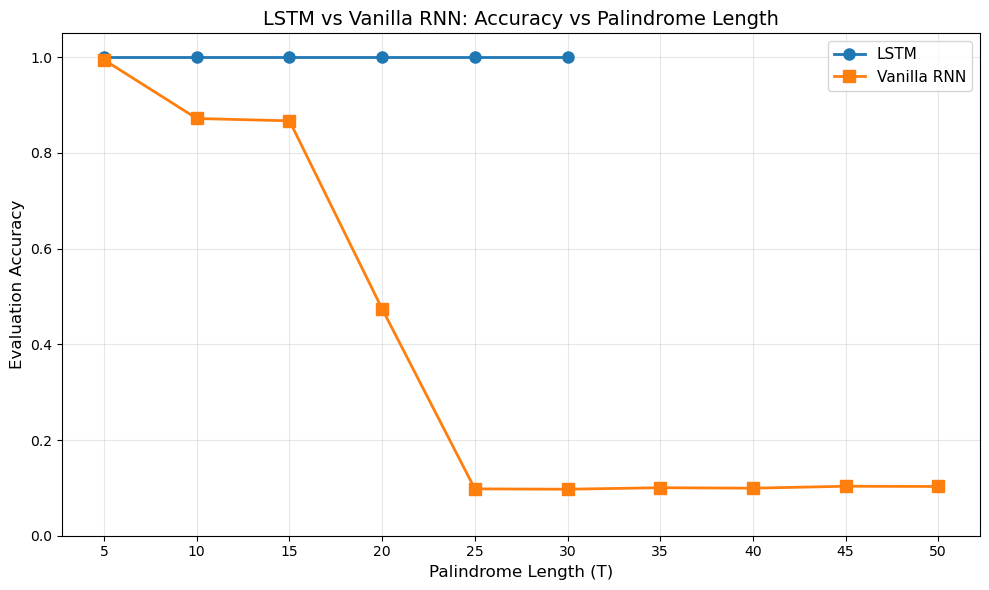

In [7]:
lstm_lengths = [entry["length"] for entry in lstm_results]
lstm_accuracies = [entry["eval_acc"] for entry in lstm_results]

rnn_lengths = [entry["length"] for entry in rnn_results]
rnn_accuracies = [entry["eval_acc"] for entry in rnn_results]

plt.figure(figsize=(10, 6))
plt.plot(lstm_lengths, lstm_accuracies, marker='o', label='LSTM', linewidth=2, markersize=8)
plt.plot(rnn_lengths, rnn_accuracies, marker='s', label='Vanilla RNN', linewidth=2, markersize=8)

plt.ylim(0, 1.05)
plt.xlabel('Palindrome Length (T)', fontsize=12)
plt.ylabel('Evaluation Accuracy', fontsize=12)
plt.title('LSTM vs Vanilla RNN: Accuracy vs Palindrome Length', fontsize=14)
plt.xticks(range(5, 55, 5))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_vs_rnn_comparison.png', dpi=150)
plt.show()

## Conclusion

The LSTM demonstrates significantly better performance than Vanilla RNN on longer sequences due to:

1. **Forget Gate**: Allows the model to selectively forget irrelevant information
2. **Input Gate**: Controls what new information to store in the cell state
3. **Output Gate**: Controls what information to output from the cell state
4. **Cell State**: Provides a highway for gradients to flow, mitigating the vanishing gradient problem

These mechanisms allow LSTM to maintain long-term dependencies much better than Vanilla RNN.